# Inspeccion de una muestra puntual

Grafica y verifica una muestra/canal especifico usando **unicamente** los
archivos ya generados (`manifest.csv`, `d03_clean_data/`, `d04_transformed_data/`),
sin volver a correr `ETL_Cleaning.ipynb`.

Caso de este notebook: **movimiento 2, muestra 144, canal `f1`**.


In [1]:
import os
import sys

import matplotlib.pyplot as plt

sys.path.insert(0, os.path.abspath(".."))  # utils/ vive en la raiz del repo
from utils import inspect_utils as iu

plt.rcParams["figure.dpi"] = 100

MOVEMENT_ID = 2
SAMPLE_INDEX = 144
SENSOR_ID = 2       # f1 vive en sensorID=2 (glove/flexion), ver etl_utils.CHANNELS_SENSOR2
CHANNEL = "f1"

manifest = iu.load_manifest()
row = iu.get_manifest_row(manifest, MOVEMENT_ID, SAMPLE_INDEX)
row

movement_id                                            2
movement_name           Bobath forward flexion/extension
limb                                               upper
sample_index                                         144
orig_index_in_raw                                    214
valid_length_sensor1                                 553
valid_length_sensor2                                 570
Name: 514, dtype: object

## Verificacion numerica de la normalizacion

Compara `clean` (grados, antes de transformar) contra `transformed` (suavizado +
z-score) sobre la region valida `[0, valid_length)`, y confirma que el padding
se mantuvo en 0.

In [2]:
result = iu.check_normalization(MOVEMENT_ID, SAMPLE_INDEX, SENSOR_ID, CHANNEL, manifest_df=manifest)
iu.print_normalization_check(result)
result

[OK] movimiento 2 (Bobath forward flexion/extension), muestra 144, canal f1 (valid_length=570)
  clean:       mean=24.3018  std=1.9431
  transformed: mean=2.04e-14  std=1.000000  (mean_ok=True, std_ok=True)
  padding fuera de valid_length es 0: True


{'movement_id': 2,
 'movement_name': 'Bobath forward flexion/extension',
 'sample_index': 144,
 'sensor_id': 2,
 'channel': 'f1',
 'valid_length': 570,
 'clean_mean': 24.301754385964912,
 'clean_std': 1.943093141673246,
 'transformed_mean': 2.041875440657972e-14,
 'transformed_std': 0.9999999945371474,
 'mean_ok': True,
 'std_ok': True,
 'padding_is_zero': True,
 'ok': True}

## raw vs. clean vs. transformed

**Importante:** `d03_clean_data`/`d04_transformed_data` fueron reindexados al eliminar muestras vacias/duplicadas en la limpieza (para el movimiento 2, de 267 filas crudas bajo a 170). Por lo tanto `sample_index=144` en los datos limpios **no** es la fila 144 del archivo crudo -- es la fila que el manifest guarda como `orig_index_in_raw`. `inspect_utils.get_sample_channel` hace esta traduccion automaticamente para `stage="raw"`/`"authors_processed"`, por eso basta con seguir pasando el mismo `SAMPLE_INDEX` de siempre.

sample_index (clean/transformed) = 144  ->  fila cruda (orig_index_in_raw) = 214


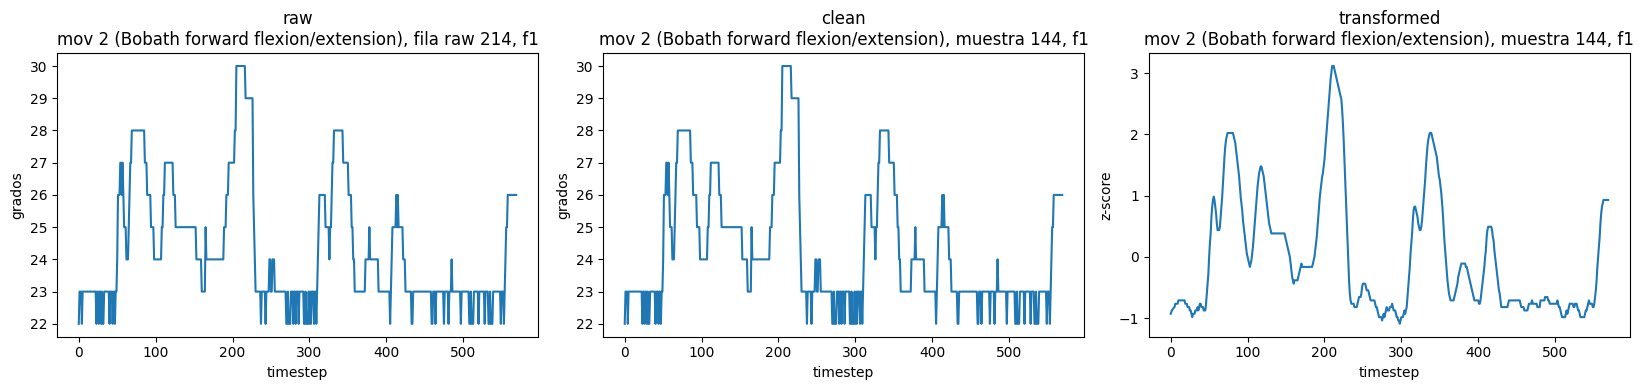

In [3]:
row = iu.get_manifest_row(manifest, MOVEMENT_ID, SAMPLE_INDEX)
print(f"sample_index (clean/transformed) = {SAMPLE_INDEX}  ->  fila cruda (orig_index_in_raw) = {row['orig_index_in_raw']}")

iu.plot_sample_channel(
    MOVEMENT_ID, SAMPLE_INDEX, SENSOR_ID, CHANNEL,
    stages=("raw", "clean", "transformed"), manifest_df=manifest,
)
plt.show()

## Contexto: los 6 canales del sensor 2 para esta misma muestra

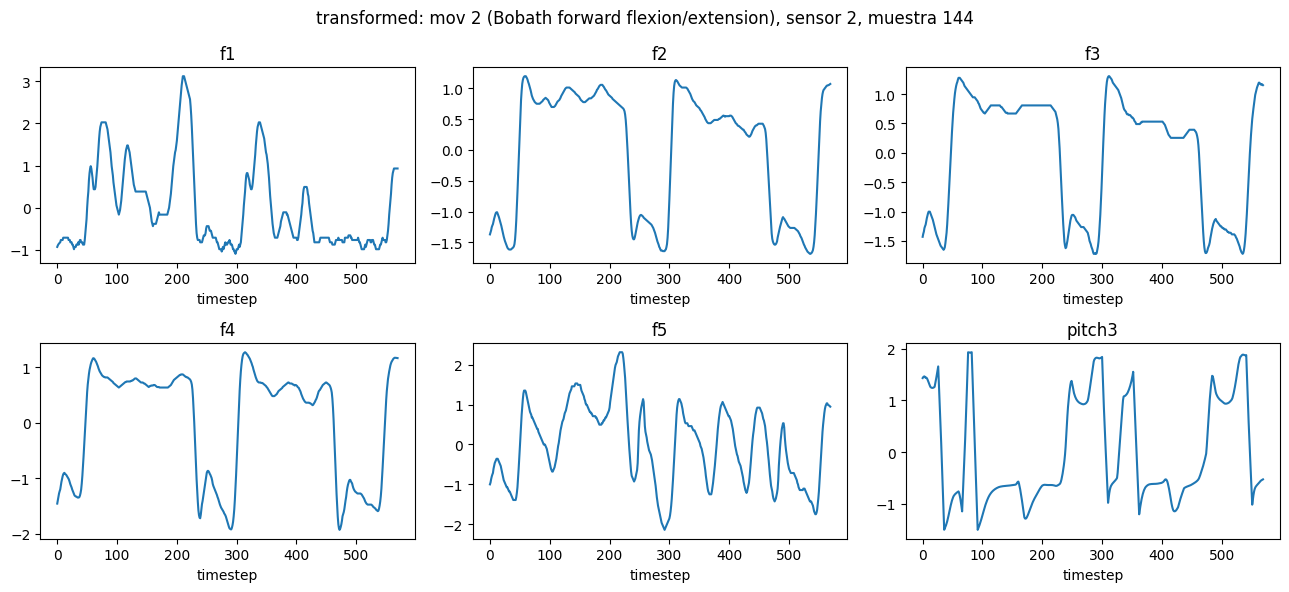

In [4]:
iu.plot_sample_all_channels("transformed", MOVEMENT_ID, SAMPLE_INDEX, SENSOR_ID, manifest_df=manifest)
plt.show()

## Mismo caso que Figure 7 de `EDA_Graphs.ipynb` (busqueda por indice crudo)

`EDA_Graphs.ipynb` indexa `d01_raw_data`/`d02_processed_data` directamente (esos archivos no fueron reindexados por la limpieza). Su Figure 7 usa movimiento `002`, fila cruda `144`. Para verla con las mismas funciones de este notebook, primero hay que traducir esa fila cruda al `sample_index` del espacio limpio con `sample_index_from_raw_index` -- **no son el mismo numero** (ver seccion anterior).

orig_index_in_raw=25  ->  sample_index=25


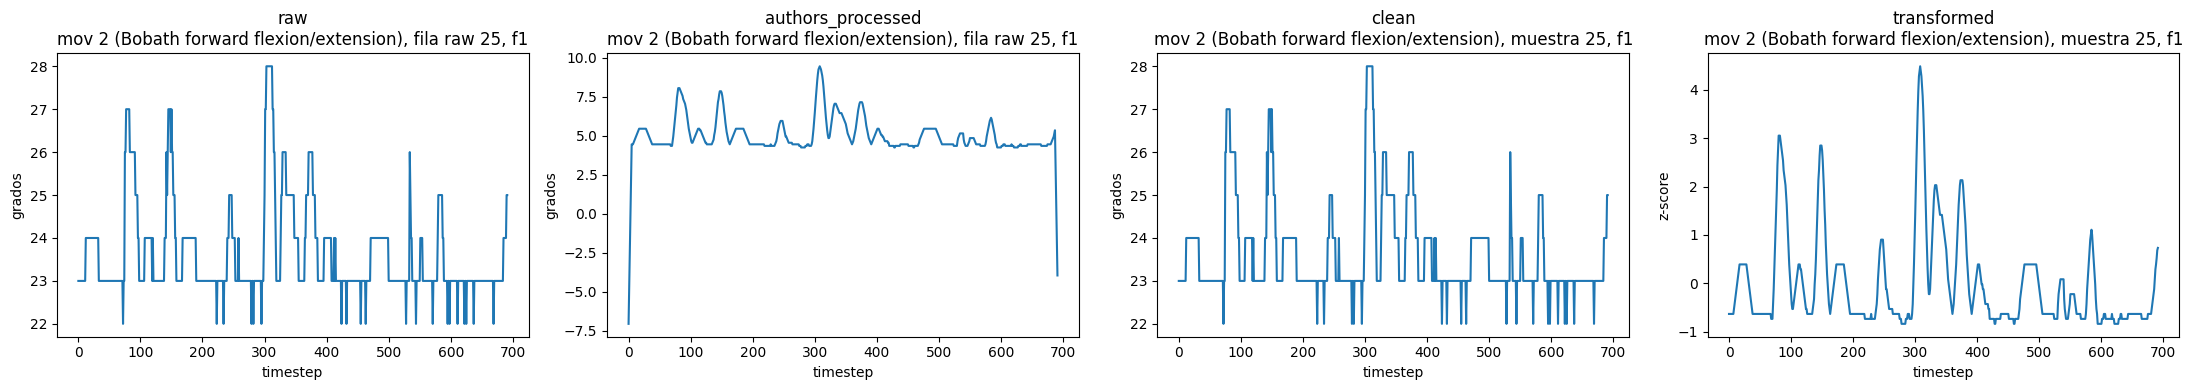

In [5]:
raw_index = 25
fig7_sample_index = iu.sample_index_from_raw_index(manifest, movement_id=MOVEMENT_ID, raw_index=raw_index)
print(f"orig_index_in_raw={raw_index}  ->  sample_index={fig7_sample_index}")

iu.plot_sample_channel(
    MOVEMENT_ID, fig7_sample_index, SENSOR_ID, CHANNEL,
    stages=("raw", "authors_processed", "clean", "transformed"), manifest_df=manifest,
)
plt.show()